Install and download dataset

In [ ]:
!pip install kaggle nibabel scikit-image scikit-learn

!kaggle datasets download -d aissahadjmahammed/radgenome-chestct-reduit-part2

import zipfile
with zipfile.ZipFile("radgenome-chestct-reduit-part2.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

Dataset URL: https://www.kaggle.com/datasets/aissahadjmahammed/radgenome-chestct-reduit-part2
License(s): DbCL-1.0
100% 9.81G/9.81G [04:57<00:00, 35.4MB/s]



Imports

In [ ]:
import os
import numpy as np
import torch
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

Preprocessing functions

In [ ]:
from scipy.ndimage import gaussian_filter

def load_ct_scan(path):
    return nib.load(path).get_fdata()

def normalize(scan):
    return (scan - scan.min()) / (scan.max() - scan.min() + 1e-8)

def denoise(scan):
    return gaussian_filter(scan, sigma=1)

def lung_segmentation(scan):
    mask = scan > 0.1
    return scan * mask

Load File Paths

In [ ]:
files = [
    os.path.join("dataset", f)
    for f in os.listdir("dataset")
    if f.endswith(".nii")
]

print("Total scans:", len(files))

Total scans: 218


General pseudo code

In [ ]:
def generate_label(scan):
    # simple heuristic: high mean intensity = abnormal
    mean_val = np.mean(scan)
    return 1 if mean_val > 0.5 else 0

Train Test split

In [ ]:
train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)

Dataset Class

In [ ]:
class CTDataset(Dataset):
    def __init__(self, file_list):
        self.files = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]

        scan = load_ct_scan(path)
        scan = denoise(scan)
        scan = normalize(scan)
        scan = lung_segmentation(scan)

        # resize
        scan = resize(scan, (32,32,32))

        label = generate_label(scan)

        scan = torch.tensor(scan, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label)

        return scan, label

Dataloader

In [ ]:
train_dataset = CTDataset(train_files)
val_dataset = CTDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

Model

In [ ]:
import torch.nn as nn

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),
        )

    def forward(self, x):
        return self.conv(x)


class SimpleTransformer(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)

    def forward(self, x):
        x, _ = self.attn(x, x, x)
        return x


class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNEncoder()
        self.transformer = SimpleTransformer(64)
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.cnn(x)
        b, c, d, h, w = x.shape
        x = x.view(b, c, -1).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

Training Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

Training Loop

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 49.5735
Epoch 2, Loss: 17.4496
Epoch 3, Loss: 1.7867
Epoch 4, Loss: 0.9323
Epoch 5, Loss: 0.4716


Evaluation - Accuracy

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)

print("Validation Accuracy:", acc)

# Full Report
print(classification_report(all_labels, all_preds))

Validation Accuracy: 0.9772727272727273
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.93      0.96        14

    accuracy                           0.98        44
   macro avg       0.98      0.96      0.97        44
weighted avg       0.98      0.98      0.98        44



Visualization Prediction vs ground truth

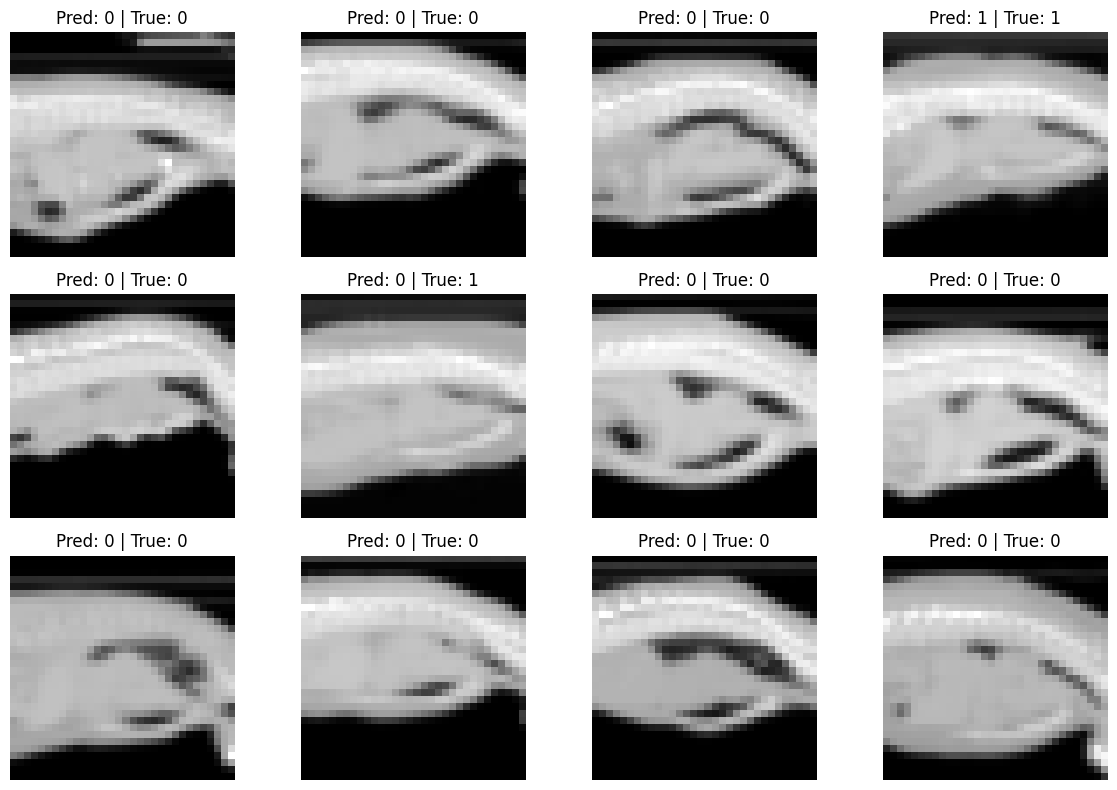

In [ ]:
import matplotlib.pyplot as plt

model.eval()

samples_shown = 0
plt.figure(figsize=(12,8))

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        for i in range(x.shape[0]):
            slice_img = x[i][0][16].cpu().numpy()  # middle slice

            plt.subplot(3,4,samples_shown+1)
            plt.imshow(slice_img, cmap="gray")
            plt.title(f"Pred: {preds[i]} | True: {y[i].item()}")
            plt.axis("off")

            samples_shown += 1
            if samples_shown == 12:
                break
        if samples_shown == 12:
            break

plt.tight_layout()
plt.show()

Confusion Metrix

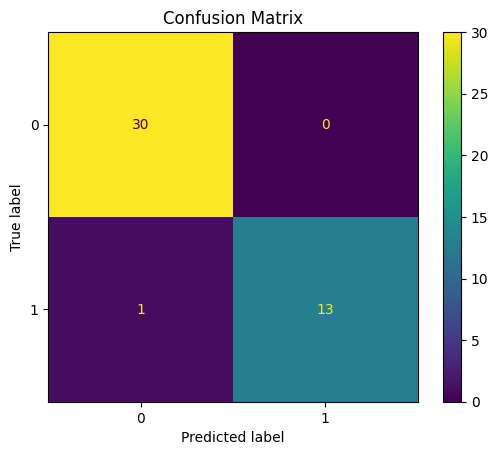

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

PCA Feature Visualization

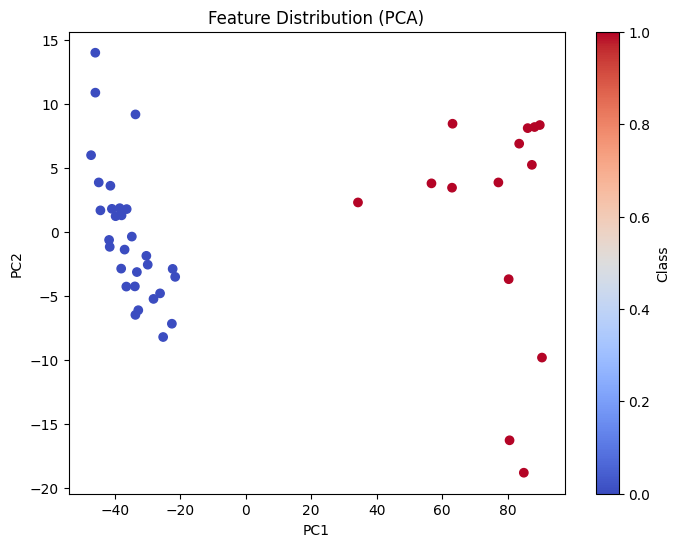

In [ ]:
from sklearn.decomposition import PCA

features_list = []

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        feat = model.cnn(x)  # extract features

        feat = feat.view(feat.size(0), -1)
        features_list.append(feat.cpu().numpy())

features_array = np.vstack(features_list)

pca = PCA(n_components=2)
reduced = pca.fit_transform(features_array)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=all_labels, cmap="coolwarm")
plt.title("Feature Distribution (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class")
plt.show()

Grad-Cam - Model Explaination

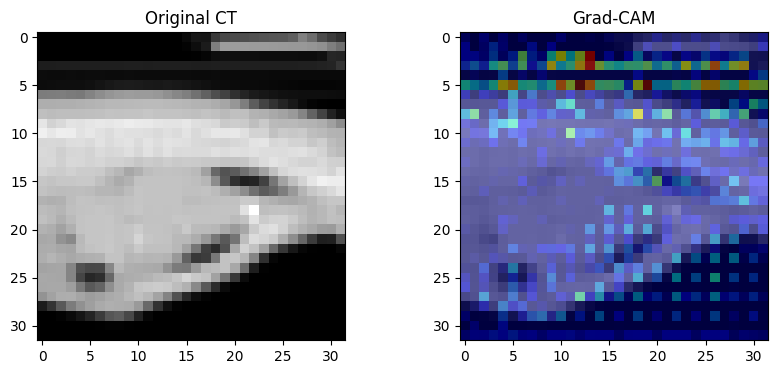

In [ ]:
def gradcam(model, input_tensor):
    input_tensor.requires_grad = True

    output = model(input_tensor)
    class_idx = output.argmax()

    output[0, class_idx].backward()

    gradients = input_tensor.grad
    heatmap = gradients.mean(dim=1).squeeze().detach().cpu().numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)

    return heatmap


# Run on one sample
x, y = next(iter(val_loader))
x = x.to(device)

heatmap = gradcam(model, x[0:1])
heatmap = np.resize(heatmap, (32,32))

slice_img = x[0][0][16].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(slice_img, cmap="gray")
plt.title("Original CT")

plt.subplot(1,2,2)
plt.imshow(slice_img, cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title("Grad-CAM")

plt.show()

Training Loss Curve

In [ ]:
losses = []

for epoch in range(EPOCHS):
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 0.4474
Epoch 2, Loss: 0.1952
Epoch 3, Loss: 0.3086
Epoch 4, Loss: 0.1294
Epoch 5, Loss: 0.2894


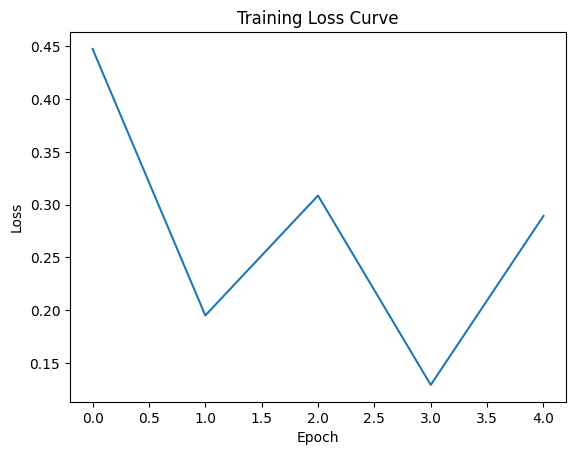

In [ ]:
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

ROC Curve and AUC

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        outputs = model(x)

        # 🔥 Convert logits → probabilities
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

In [ ]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 1.0


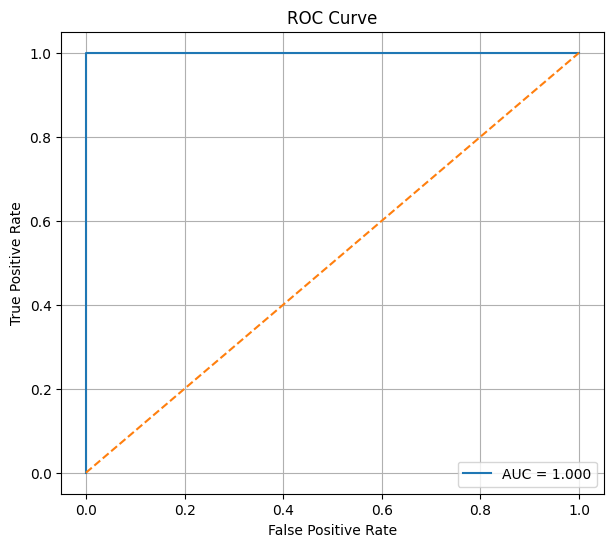

In [ ]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")  # random baseline

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

Precision Recall Curve

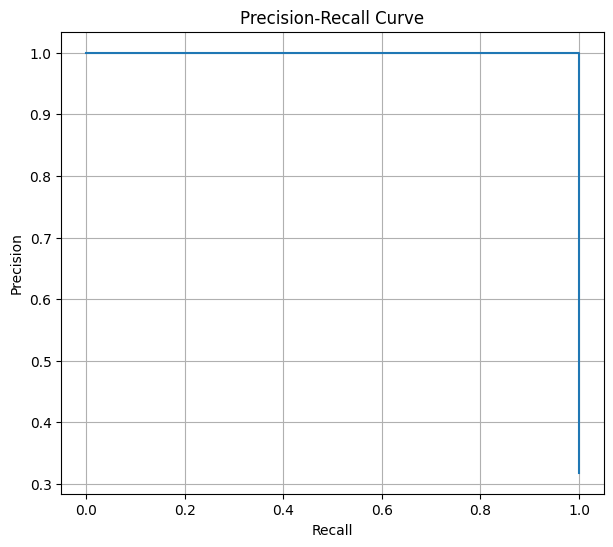

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

3D Visualization

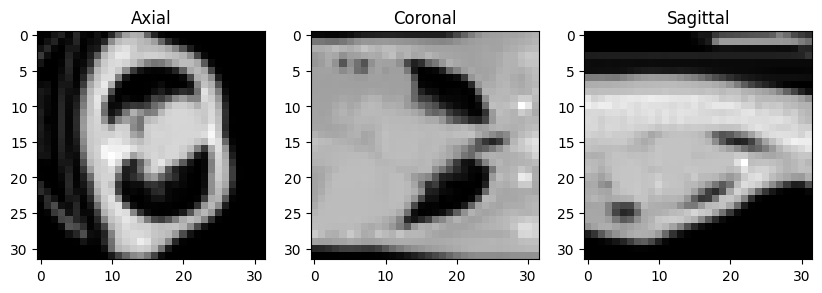

In [ ]:
x_batch, _ = next(iter(val_loader))
scan = x_batch[0, 0].cpu().numpy() # Get the first scan from the batch

slice_idx = scan.shape[2] // 2

plt.figure(figsize=(10,4))

# Axial
plt.subplot(1,3,1)
plt.imshow(scan[:,:,slice_idx], cmap="gray")
plt.title("Axial")

# Coronal
plt.subplot(1,3,2)
plt.imshow(scan[:,slice_idx,:], cmap="gray")
plt.title("Coronal")

# Sagittal
plt.subplot(1,3,3)
plt.imshow(scan[slice_idx,:,:], cmap="gray")
plt.title("Sagittal")

plt.show()

In [ ]:
import nibabel as nib
import plotly.graph_objects as go
from skimage import measure

# The lung_segmentation function is already defined in the notebook.
# The 'scan' variable is available from previous cells (e.g., DFUjUk7wbvbX and PE59xMBKcP4Z).
# If running this cell independently, you would need to define file_path and load/normalize the scan first.
# For example:
# file_path = val_files[0] # or another specific path
# scan = nib.load(file_path).get_fdata()
# scan = (scan - scan.min()) / (scan.max() - scan.min())

# Apply lung segmentation
lung = lung_segmentation(scan)

verts, faces, _, _ = measure.marching_cubes(lung, level=0.1)

fig = go.Figure(data=[
    go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        color='lightblue',
        opacity=0.3
    )
])

fig.update_layout(title="3D Lung Segmentation")
fig.show()